# 2. Comparing categories

**The question: how do these groups differ?**

Half of this notebook is the toolkit — bar charts, grouped bars, heatmaps, and the design
decisions that make them readable. The other half is the reason group comparisons go wrong
more often than any other kind, which is that *the same data grouped differently gives
different answers*.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from goad_toolkit.visualizer import BasePlot, PlotSettings

from wa_analyzer.data import load_own_chat, load_showcase


## 2.1 A plot class of your own

In lesson 1 you subclassed `TransformBase` to add a pipeline step. `goad_toolkit` has a
second extension point with the same shape: `BasePlot`.

**The problem it solves.** A chart in a notebook starts as one seaborn call and ends as
this, in every cell that draws anything:

```python
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=penguins, x="species", y="body_mass_g", ax=ax, order=order)
ax.set_title("Body mass by species")
ax.set_xlabel("species")
ax.set_ylabel("body mass (g)")
ax.grid(True, alpha=0.3)
```

Six lines, of which one is the chart and five are makeup. Copy that into fifteen cells and
the makeup is now duplicated fifteen times — so "make every figure wider" is fifteen edits,
and the one cell you miss is the one in your report.

The class version splits those two jobs apart:

```python
class BarPlot(BasePlot):
    def build(self, data, x, y, **kwargs):
        sns.barplot(data=data, x=x, y=y, ax=self.ax, **kwargs)
        return self.fig, self.ax

settings = PlotSettings(figsize=(8, 4), title="Body mass by species",
                        xlabel="species", ylabel="body mass (g)")
fig, ax = BarPlot(settings).plot(data=penguins, x="species", y="body_mass_g", order=order)
```

`PlotSettings` carries the *makeup*; your subclass carries the *drawing*. Now "make every
figure wider" is one edit to one settings object, and the chart classes never knew.

**What the base class guarantees.** `plot()` runs `create_figure()` before it calls your
`build()`. So by the time your code runs, you already have:

- `self.fig` and `self.ax`, created at `settings.figsize` — you never call `plt.subplots`;
- the title, axis labels and grid already applied from the settings;
- for `n_plots > 1`, a grid of subplots (max three columns) with the unused axes hidden.

Your `build` therefore has exactly one job — draw on `self.ax` — and one obligation: **return
`(self.fig, self.ax)`**, because that is what callers and `plot_on` chain on.

One consequence worth knowing, because it looks like magic until it does not. Seaborn labels
axes with your column names, but only when the label is still empty — and `PlotSettings` got
there first. So the settings always win, and the defaults are literally `"Plot"`, `"X"` and
`"Y"`. **A chart with `X` and `Y` on the axes is not a seaborn quirk; it is a `PlotSettings`
you forgot to fill in.**

**Where this pays off later.** Same as with transforms: most of what you need is already a
subclass. Thirteen ship in `goad_toolkit` — lesson 4 imports `HistogramPlot`, `QQPlot` and
`DistPlot` and never writes a `build` at all, exactly as lesson 1 imported `TimeFeatures`
rather than writing it. You subclass for the chart nobody packaged.

The other payoff is that a plot class is *importable*. A dashboard can import `BarPlot` and
call it with its own `PlotSettings`; there is no way to import a chart that exists only as
six lines in a notebook cell. `BasePlot` also has `plot_on`, which hands one plot's figure
and axes to another so charts can be layered — worth knowing exists, for when one set of
axes has to carry two things.

In [2]:
class BarPlot(BasePlot):
    """A bar chart. All the styling lives in PlotSettings."""

    def build(self, data: pd.DataFrame, x: str, y: str, **kwargs):
        sns.barplot(data=data, x=x, y=y, ax=self.ax, **kwargs)
        return self.fig, self.ax

## 2.2 The showcase: penguins

Three species, two sexes, three islands, 344 birds. Small enough to check by hand and
different enough that a bad chart cannot hide the differences.

In [3]:
penguins = load_showcase("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


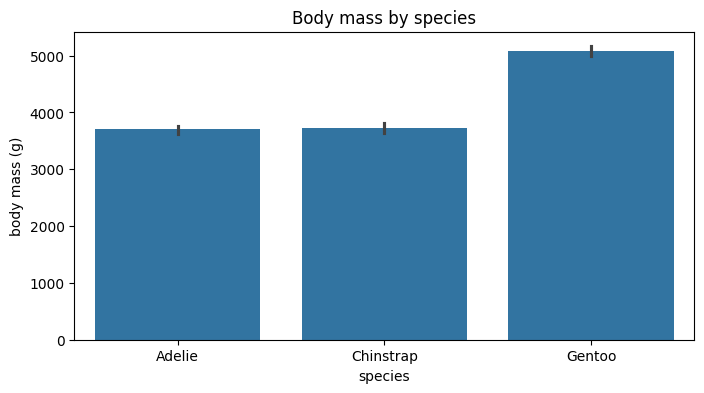

In [4]:
settings = PlotSettings(
    figsize=(8, 4),
    title="Body mass by species",
    xlabel="species",
    ylabel="body mass (g)",
)
fig, ax = BarPlot(settings).plot(data=penguins, x="species", y="body_mass_g")

### Order is a decision

Seaborn plotted the species in the order it found them. Alphabetical order, or
order-of-appearance, is almost never the order your reader needs.

**Sort by the value unless the category has its own sequence** — days of the week, age
bands, months. An unsorted bar chart makes the reader do the comparison you were supposed to
do for them.

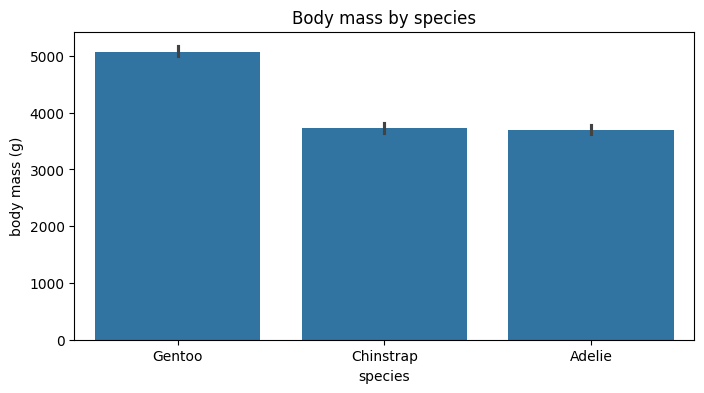

In [5]:
order = penguins.groupby("species").body_mass_g.mean().sort_values(ascending=False).index

fig, ax = BarPlot(settings).plot(data=penguins, x="species", y="body_mass_g", order=order)

### Grey first, then one colour

The fifth of the course's five guidelines. Draw everything in grey, then colour the one
thing you are talking about. Colour used this way is a pointer; colour used everywhere is
decoration that costs the reader attention and returns nothing.

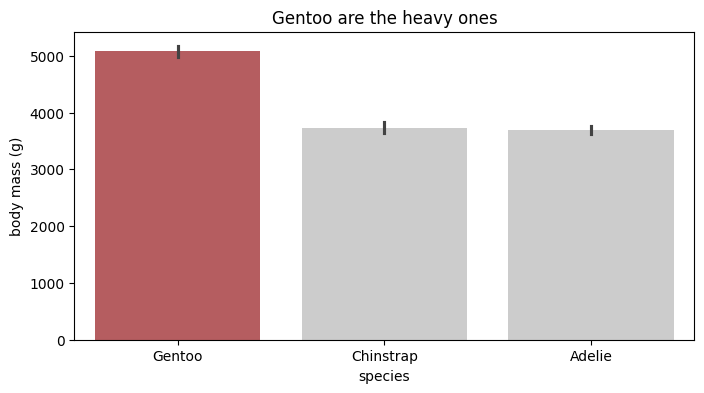

In [6]:
highlight = "Gentoo"
palette = {s: ("#c44e52" if s == highlight else "#cccccc") for s in order}

fig, ax = BarPlot(
    PlotSettings(figsize=(8, 4), title=f"{highlight} are the heavy ones",
                 xlabel="species", ylabel="body mass (g)")
).plot(data=penguins, x="species", y="body_mass_g", order=order,
       hue="species", palette=palette, legend=False)

Compare that with the default palette above. Same data, same shape — but this one has a
subject, and the title says what it is.

### Two categorical variables at once

A grouped bar when both have few levels; a heatmap when either has many.

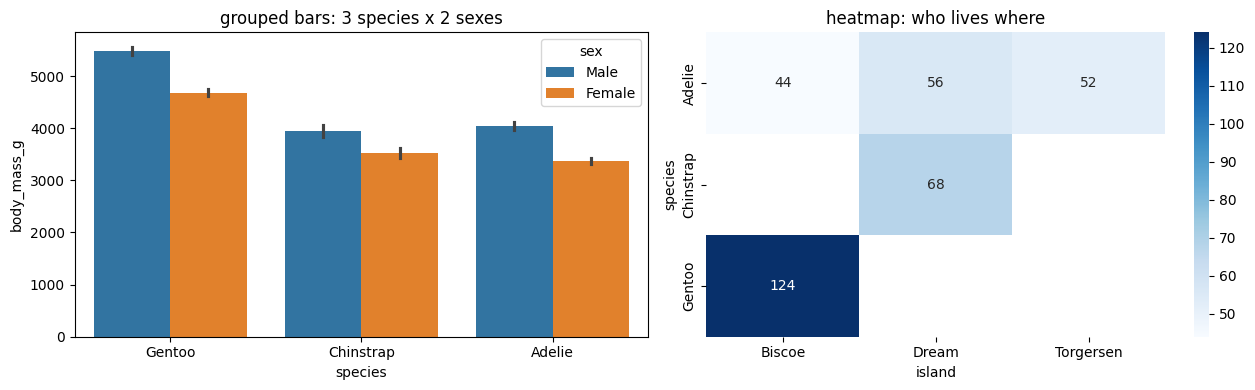

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=penguins, x="species", y="body_mass_g", hue="sex",
            order=order, ax=ax[0])
ax[0].set_title("grouped bars: 3 species x 2 sexes")

counts = penguins.pivot_table(index="species", columns="island",
                              values="body_mass_g", aggfunc="size")
sns.heatmap(counts, annot=True, fmt=".0f", cmap="Blues", ax=ax[1])
ax[1].set_title("heatmap: who lives where")
plt.tight_layout()

The heatmap answers a question the bars cannot: Gentoo and Chinstrap each live on exactly
one island, Adelie on all three. That is a fact about the *design of the data*, and it is
the kind of thing worth knowing before you compare anything — a species/island comparison is
partly a comparison of islands.

## 2.3 Three ways a group comparison misleads

### Too many bars, in no order

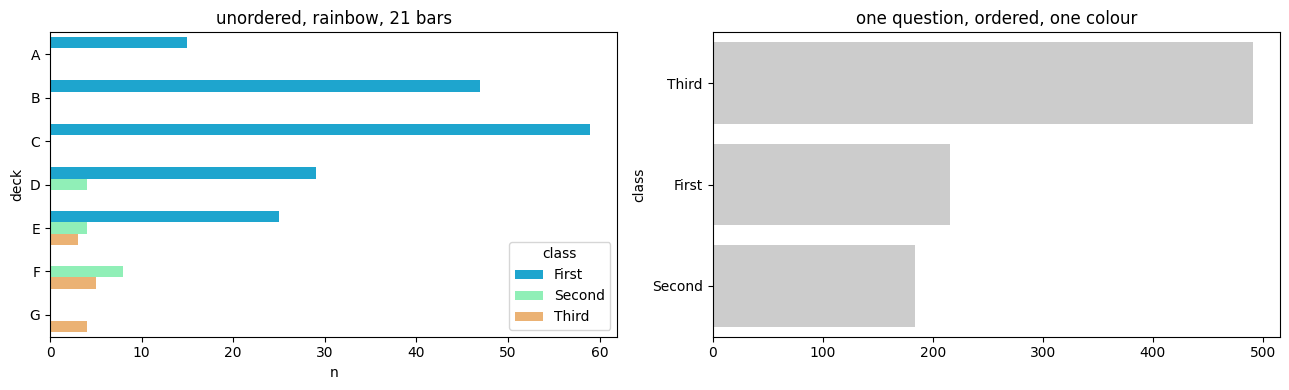

In [8]:
titanic = load_showcase("titanic")
by_deck = titanic.groupby(["deck", "class"], observed=True).size().reset_index(name="n")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=by_deck, x="n", y="deck", hue="class", ax=ax[0], palette="rainbow")
ax[0].set_title("unordered, rainbow, 21 bars")

top = titanic.groupby("class", observed=True).size().sort_values(ascending=False)
sns.barplot(x=top.values, y=top.index, ax=ax[1], color="#cccccc")
ax[1].set_title("one question, ordered, one colour")
plt.tight_layout()

The left chart is not wrong. It is unreadable, which amounts to the same thing.

### A proportion without its denominator

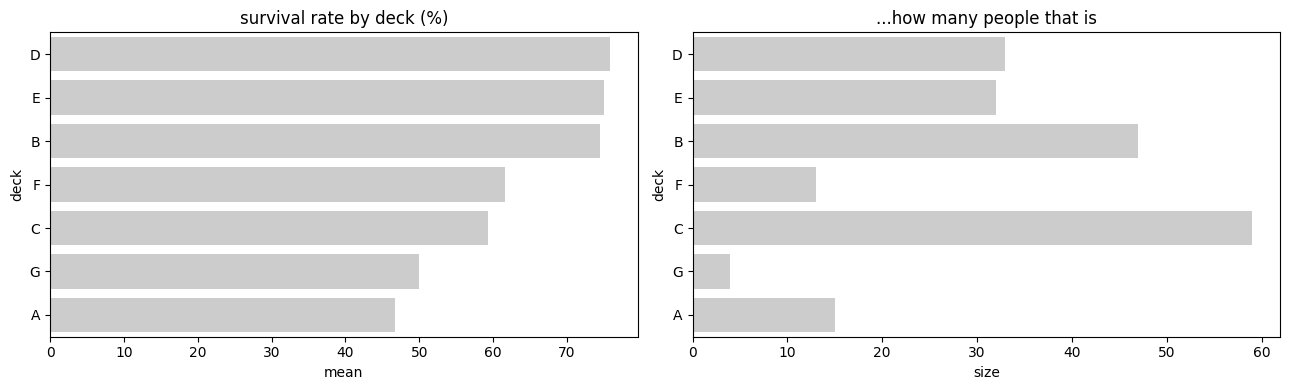

In [9]:
rate = titanic.groupby("deck", observed=True).survived.agg(["mean", "size"])
rate = rate.sort_values("mean", ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=rate["mean"] * 100, y=rate.index, ax=ax[0], color="#cccccc")
ax[0].set_title("survival rate by deck (%)")
sns.barplot(x=rate["size"], y=rate.index, ax=ax[1], color="#cccccc")
ax[1].set_title("...how many people that is")
plt.tight_layout()

Deck G has a survival rate you could write a headline about, and four people on it.

Whenever you plot a proportion, plot or annotate the count behind it. A rate over a handful
of cases is mostly noise, and the bar chart gives it exactly the same visual weight as a
rate over hundreds.

### Simpson's paradox

Berkeley graduate admissions, 1973. The six largest departments, the numbers as published.

In [10]:
berkeley = load_showcase("berkeley_admissions")

overall = berkeley.groupby("gender")[["applied", "admitted"]].sum()
overall["rate"] = overall.admitted / overall.applied
overall.round(3)

,applied,admitted,rate
gender,,,
men,2691,1198,0.445
women,1835,557,0.304


44.5% of men admitted, 30.4% of women. That looks decisive.

Now the same numbers, per department.

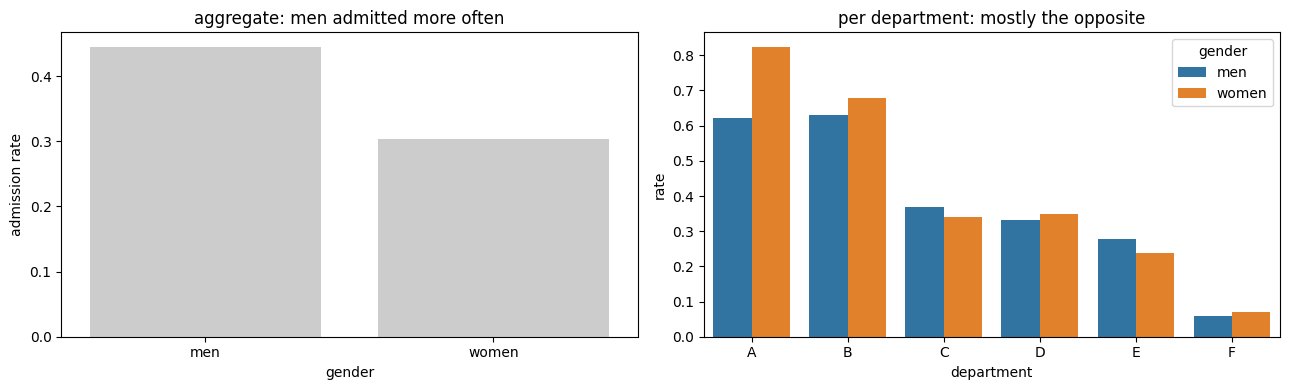

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=overall.reset_index(), x="gender", y="rate", ax=ax[0], color="#cccccc")
ax[0].set_title("aggregate: men admitted more often")
ax[0].set_ylabel("admission rate")

sns.barplot(data=berkeley, x="department", y="rate", hue="gender", ax=ax[1])
ax[1].set_title("per department: mostly the opposite")
plt.tight_layout()

In [12]:
wide = berkeley.pivot(index="department", columns="gender", values="rate")
wide["women_higher"] = wide.women > wide.men
print(wide.round(3).to_string())
print(f"\nwomen admitted at a higher rate in {wide.women_higher.sum()} of {len(wide)} departments")

gender        men  women  women_higher
department                            
A           0.621  0.824          True
B           0.630  0.680          True
C           0.369  0.341         False
D           0.331  0.349          True
E           0.278  0.239         False
F           0.059  0.070          True

women admitted at a higher rate in 4 of 6 departments


The aggregate favours men; four of the six departments favour women. Nothing is
miscalculated — both statements are true of the same table.

The resolution is in the application counts: women applied in far larger numbers to the
departments that admitted almost nobody, and men to the departments that admitted most
people. The aggregate is measuring *which department people applied to*, not how they were
treated once there.

**The defence, and it is a question you can ask every time:** is there a variable that
differs between these groups and also affects the outcome? If yes, compare within it.

## 2.4 The same trap, on your kind of data

Simpson's paradox needed a hidden grouping variable. There is a second version that needs
nothing but a careless choice of what to count, and it is the one that catches students.

Back to the IRC corpus from lesson 1.

In [13]:
import re

irc = load_showcase("ubuntu_irc")
pattern = re.compile(r"^\[(\d{2}):(\d{2})\]\s+<(\S+)>\s+(.*)$")
action = re.compile(r"^\[(\d{2}):(\d{2})\]\s+\*\s+(\S+)\s+(.*)$")

rows = []
for day in irc.itertuples():
    for line in day.text.split("\n"):
        m = pattern.match(line) or action.match(line)
        if m:
            rows.append((day.channel, m.group(3), m.group(4)))

msgs = pd.DataFrame(rows, columns=["channel", "author", "message"])
msgs["length"] = msgs.message.str.len()
print(f"{len(msgs):,} messages, {msgs.author.nunique():,} authors")

627,172 messages, 4,747 authors


**The question: do people in one channel write longer messages than people in the other?**

Note the wording. It is a claim about *people*. Keep that in mind, and count messages.

In [14]:
by_message = msgs.groupby("channel").length.agg(["size", "mean", "sem"])
by_message["ci95"] = 1.96 * by_message["sem"]
by_message.round(2)

,size,mean,sem,ci95
channel,,,,
#ubuntu-nl,116339,49.50,0.14,0.28
#ubuntu-uk,510833,48.35,0.06,0.12


`#ubuntu-uk` messages are about a character shorter, and with half a million of them the
interval is ±0.12. As clear as data gets.

Now count people. Each author gets one number — their own average — and each author counts
once, however much they wrote.

In [15]:
per_author = msgs.groupby(["channel", "author"]).length.agg(["size", "mean"])
per_author = per_author[per_author["size"] >= 30].reset_index()

by_author = per_author.groupby("channel")["mean"].agg(["size", "mean", "sem"])
by_author["ci95"] = 1.96 * by_author["sem"]
by_author.round(2)

,size,mean,sem,ci95
channel,,,,
#ubuntu-nl,504,48.88,0.86,1.68
#ubuntu-uk,442,55.35,1.78,3.49


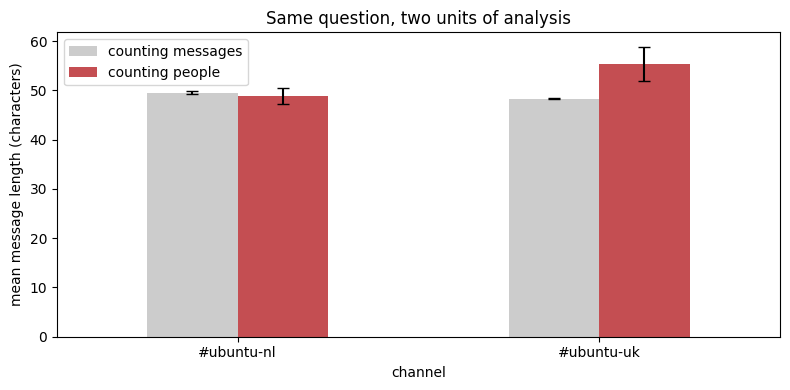

In [16]:
compare = pd.DataFrame({
    "counting messages": by_message["mean"],
    "counting people": by_author["mean"],
})
err = pd.DataFrame({
    "counting messages": by_message["ci95"],
    "counting people": by_author["ci95"],
})

ax = compare.plot.bar(yerr=err, figsize=(8, 4), rot=0,
                      color=["#cccccc", "#c44e52"], capsize=4)
ax.set_ylabel("mean message length (characters)")
ax.set_title("Same question, two units of analysis")
plt.tight_layout()

The answer **changes sign**. Counting messages, `#ubuntu-uk` is shorter by 1.2 characters.
Counting people, `#ubuntu-uk` is longer by 6.5.

Both numbers are correct. They answer different questions:

- *counting messages* — "if I pick a random message from this channel, how long is it?"
- *counting people* — "if I pick a random regular of this channel, how long are their messages?"

The claim we made was about people. Only one of these tests it.

### Why it flips

Two things pull in opposite directions.

In [17]:
top8 = msgs[msgs.channel == "#ubuntu-uk"].author.value_counts().head(8)
uk = per_author[per_author.channel == "#ubuntu-uk"]

print(f"top 8 authors write {top8.sum() / (msgs.channel == '#ubuntu-uk').sum():.0%} "
      f"of #ubuntu-uk's messages\n")
print("the four most verbose authors, and how much they actually wrote:")
print(uk.nlargest(4, "mean")[["author", "size", "mean"]].round(1).to_string(index=False))

top 8 authors write 44% of #ubuntu-uk's messages

the four most verbose authors, and how much they actually wrote:
     author  size  mean
tiiiiiirnot    32 426.0
   warni521    44 318.8
      dipre    44 291.9
       tox`    36 290.8


The message-level mean is dominated by the eight regulars who write 44% of everything, and
they are terse. The author-level mean gives one vote each to accounts like `tiiiiiirnot` —
32 messages averaging 426 characters, which you met in lesson 1 as a flood.

That is the part worth carrying: **the fewer units you have, the more one bad unit moves the
answer.** Cleaning matters more, not less, when you aggregate up to people.

Neither unit is the right one in general. The right one is the one your sentence is about.

> **Ask this every time you compare groups:**
>
> 1. What is my claim about — messages, people, days, conversations?
> 2. Is that the thing I counted?
> 3. How many of them are there? Not rows. Units.

## 2.5 Your turn

Your own chat has far fewer people than IRC does, which makes all of the above sharper
rather than softer.

In [ ]:
own = load_own_chat()

In [ ]:
if own is not None:
    own["length"] = own.message.str.len()
    per_person = own.groupby("author").length.agg(["size", "mean"]).sort_values("mean")
    print(f"{len(per_person)} people, {len(own):,} messages\n")
    display(per_person.round(1))
else:
    print("No chat of your own yet — the showcase above still stands.")

In [ ]:
if own is not None:
    counts = own.author.value_counts().sort_values(ascending=False)
    fig, ax = BarPlot(
        PlotSettings(figsize=(8, 4), title="Messages per person",
                     xlabel="messages", ylabel="")
    ).plot(data=counts.reset_index(), x="count", y="author", color="#cccccc")

> **Your turn.**
>
> 1. Make one bar chart that answers a question you actually have about your chat. Order it,
>    grey it, and colour the one bar your title is about.
> 2. Pick a comparison between two people or two groups. Compute it counting messages, then
>    counting people. Do they agree?
> 3. Write down how many *people* your claim rests on.

## 2.6 What to write down

1. **One comparison, stated as a sentence** — "X sends more/longer/later than Y".
2. **The unit that sentence is about**, and the number of units behind it.
3. **One grouping variable you checked for** — anything that differs between your groups and
   could also affect the outcome.
4. **The chart, with its order and colour chosen deliberately**, and a title that states the
   finding rather than naming the axes.

---

**Where this goes next.** Lesson 3 takes the same comparisons and puts time on the x-axis,
where a new failure appears: the difference between a pattern and the way you smoothed it.